In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MeanShift
import random

In [2]:
np.random.seed(84)
random.seed(84)

In [3]:
pd.options.display.max_seq_items = 2000

In [4]:
reconciled_data = pd.read_pickle('reconciled_data.pkl')

data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

X = data[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

data['cluster'] = clustering.labels_

cluster_set = list(set(data.cluster))

index_clusters = data.groupby('cluster').T_R_C.mean().sort_values().index.values

val_clusters = index_clusters[[2, 4]]
test_clusters = index_clusters[[6]]
train_clusters = index_clusters[[0,1,3,5]]

loc_validation = data['cluster'].isin(val_clusters)
loc_training =  data['cluster'].isin(train_clusters)
loc_test = data['cluster'].isin(test_clusters)

idx_validation = loc_validation.loc[loc_validation].index
idx_training = loc_training.loc[loc_training].index
idx_test = loc_test.loc[loc_test].index

data['training'] = loc_training

In [5]:
data.groupby(['cluster'])['T_R_C'].mean().sort_values()

cluster
3    211.000000
0    222.000000
2    233.000000
1    243.687500
6    253.500000
5    262.545455
4    271.000000
Name: T_R_C, dtype: float64

In [6]:
Ns_parafins = {
    'F_CH4_s_mol_s': 1, 'F_C2H6_s_mol_s': 2, 'F_C3H8_s_mol_s': 3,
       'F_C9': 9, 'F_C10': 10, 'F_C11': 11, 'F_C12': 12, 'F_C13': 13, 'F_C14': 14, 'F_C15': 15, 'F_C16': 16,
       'F_C17': 17, 'F_C18': 18, 'F_C19': 19, 'F_C20': 20, 'F_C21': 21, 'F_C22': 22, 'F_C23': 23, 'F_C24': 24,
       'F_C25': 25, 
       # 'F_C26': 26, 'F_C27': 27, 'F_C28': 28, 'F_C29': 29, 'F_C30': 30,
       # 'F_C31': 31, 'F_C32': 32,
       # 'F_C33': 33, 'F_C34': 34,
       # 'F_C35': 35, 
       # 'F_C36': 36,
}
Ns_olefins = {
    'F_C2H4_s_mol_s': 2,
       'F_Olef_C9': 9, 'F_Olef_C10': 10,
       'F_Olef_C11': 11, 'F_Olef_C12': 12, 'F_Olef_C13': 13, 'F_Olef_C14': 14, 'F_Olef_C15': 15,
       # 'F_Olef_C16': 16, 'F_Olef_C17': 17, 
       # 'F_Olef_C18': 18, 
}

In [7]:
MM_parafins = {comp: n * 12 + 2 * n + 2 for comp, n in Ns_parafins.items()}
MM_olefins = {comp: n * 12 + 2 * n for comp, n in Ns_olefins.items()}

In [8]:
Fn_exp_parafins = data[list(Ns_parafins.keys())]

Fn_exp_olefins = data[list(Ns_olefins.keys())]

mn_exp_parafins = Fn_exp_parafins.mul(MM_parafins, axis = 'columns')
mn_exp_olefins = Fn_exp_olefins.mul(MM_olefins, axis = 'columns')

Fn_exp_parafins.columns = Ns_parafins.values()
Fn_exp_parafins.columns = Fn_exp_parafins.columns.astype('int32')

mn_exp_parafins.columns = Ns_parafins.values()
mn_exp_parafins.columns = mn_exp_parafins.columns.astype('int32')

Fn_exp_olefins.columns = Ns_olefins.values()
Fn_exp_olefins.columns = Fn_exp_olefins.columns.astype('int32')

mn_exp_olefins.columns = Ns_olefins.values()
mn_exp_olefins.columns = mn_exp_olefins.columns.astype('int32')

In [9]:
Fn_exp = Fn_exp_parafins.copy()
mn_exp = mn_exp_parafins.copy()

In [10]:
for i in Ns_olefins.values():
    Fn_exp[i] = Fn_exp[i] + Fn_exp_olefins[i]
    mn_exp[i] = mn_exp_parafins[i] + mn_exp_olefins[i]

In [11]:
# drop rows with zeros
Fn_exp = Fn_exp[(Fn_exp != 0).all(axis=1)]
Fn_exp = Fn_exp.astype('float')

mn_exp = mn_exp[(mn_exp != 0).all(axis=1)]
mn_exp = mn_exp.astype('float')

In [12]:
data = data.loc[Fn_exp.index].copy()

In [13]:
yn_exp = Fn_exp.div(Fn_exp.sum(axis = 'columns'), axis = 'rows')
omega_n_exp = mn_exp.div(mn_exp.sum(axis = 'columns'), axis = 'rows')

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [15]:
alphas = data[['T_R_K', 'H2_CO', 'P_abs_Pa']]

In [16]:
yn_exp_train = yn_exp
# yn_exp_train = yn_exp_train[(yn_exp_train != 0).all(axis=1)]
yn_exp_train = yn_exp_train.drop(columns = [2,9,10])
for i in yn_exp_train.index:
    x = (yn_exp_train.columns.values - 1).reshape(-1, 1)
    y = np.log(yn_exp_train.loc[i].values)
        
    model = LinearRegression()
    model.fit(x, y) # Fit the model to the training data
    
    r_sq = model.score(x, y) # Evaluate on the test set

    alphas.loc[i, 'alpha'] = np.exp(model.coef_[0])
    alphas.loc[i, 'R² alpha'] = r_sq

In [17]:
alphas = alphas.astype('float')

In [18]:
alphas.columns

Index(['T_R_K', 'H2_CO', 'P_abs_Pa', 'alpha', 'R² alpha'], dtype='str')

In [19]:
alphas['training'] = data.training

In [20]:
x = alphas.loc[loc_training].T_R_K.values.reshape(-1, 1)
y = alphas.loc[loc_training].alpha.values

model_alpha_T = LinearRegression()
model_alpha_T.fit(x, y) # Fit the model to the training data

alphas['alpha_model']  = model_alpha_T.predict(alphas.T_R_K.values.reshape(-1, 1))

In [21]:
model_alpha_T.coef_[0]

np.float64(-0.0014949717120423726)

In [22]:
model_alpha_T.intercept_

np.float64(1.6262887231230656)

In [23]:
alpha_params = np.array((model_alpha_T.intercept_, model_alpha_T.coef_[0]))

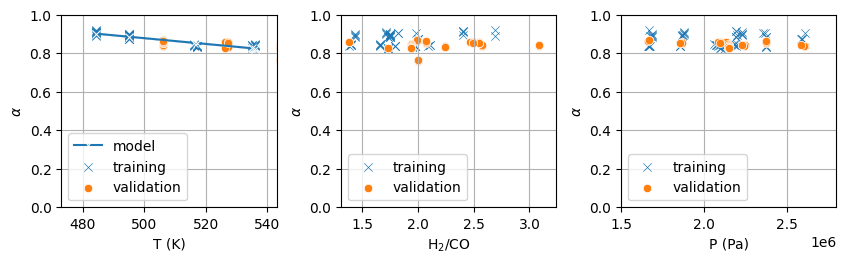

In [36]:
fig, ax = plt.subplots(1,3,figsize=(10,2.5))
plt.subplots_adjust(wspace=0.3)

colors = sns.color_palette()

ax[0].set_xlim(200+273, 270+273)
# sns.regplot(x='T_R_K', y='alpha', data=alphas.loc[data.training], ax = ax[0],
#            line_kws = {'lw': 1.5}, scatter_kws = {'s': 20},
#            label = 'training', marker = 'x', color = colors[0], truncate=False
#            )
sns.lineplot(x='T_R_K', y='alpha_model', data=alphas.loc[data.training],
                ax = ax[0], label = 'model', marker = 'x', color = colors[0])
sns.scatterplot(x='T_R_K', y='alpha', data=alphas.loc[data.training],
                ax = ax[0], label = 'training', marker = 'x', color = colors[0])
sns.scatterplot(x='T_R_K', y='alpha', data=alphas.loc[~data.training],
                ax = ax[0], label = 'validation', marker = 'o', color = colors[1])

ax[0].grid('both')
ax[0].set_ylim(0,1)
ax[0].set_ylabel(r'$\alpha$')
ax[0].set_xlabel('T (K)')

ax[1].set_xlim(0.95 * alphas.H2_CO.min(), 1.05 * alphas.H2_CO.max())
# sns.regplot(x='H2_CO', y='alpha', data=alphas.loc[alphas.training], ax = ax[1],
#            line_kws = {'lw': 1.5}, scatter_kws = {'s': 20},
#            label = 'training', marker = 'x', color = colors[0], truncate=False
#            )
sns.scatterplot(x='H2_CO', y='alpha', data=alphas.loc[alphas.training],
                ax = ax[1], label = 'training', marker = 'x', color = colors[0])
sns.scatterplot(x='H2_CO', y='alpha', data=alphas.loc[~alphas.training],
                ax = ax[1], label = 'validation', marker = 'o', color = colors[1])
ax[1].grid('both')
ax[1].set_ylim(0,1)
ax[1].set_ylabel(r'$\alpha$')
ax[1].set_xlabel(r'$\mathrm{H_2 / CO}$')

ax[1].set_xlim(0.95 * alphas.H2_CO.min(), 1.05 * alphas.H2_CO.max())
# sns.regplot(x='P_abs_Pa', y='alpha', data=alphas.loc[alphas.training], ax = ax[2],
#            line_kws = {'lw': 1.5}, scatter_kws = {'s': 20},
#            label = 'training', marker = 'x', color = colors[0], truncate=False
#            )
sns.scatterplot(x='P_abs_Pa', y='alpha', data=alphas.loc[alphas.training],
                ax = ax[2], label = 'training', marker = 'x', color = colors[0])
sns.scatterplot(x='P_abs_Pa', y='alpha', data=alphas.loc[~alphas.training],
                ax = ax[2], label = 'validation', marker = 'o', color = colors[1])
ax[2].grid('both')
ax[2].set_ylim(0,1)
ax[2].set_xlim(15e5,28e5)
ax[2].set_ylabel(r'$\alpha$')
ax[2].set_xlabel('P (Pa)')

fig_name = 'alpha.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

plt.show()

In [25]:
# visualizing yn
yn_plot = yn_exp.copy()
yn_plot['T_R_K'] = data.T_R_K
yn_plot['T_R_C'] = data.T_R_C
yn_plot['H2_CO'] = data.H2_CO
yn_plot['P_Pa'] = data.P_abs_Pa
yn_plot['index'] = data.index.values
yn_plot = yn_plot.melt(id_vars = ['T_R_K', 'T_R_C', 
                                  'H2_CO', 'P_Pa', 'index'], value_name = 'yn_exp', var_name = 'n')
yn_plot['alpha'] = model_alpha_T.predict(yn_plot.T_R_K.values.reshape(-1, 1))
yn_plot['yn_model'] = ( 1 - yn_plot.alpha.values ) * yn_plot.alpha.values ** ( yn_plot.n.values - 1 )

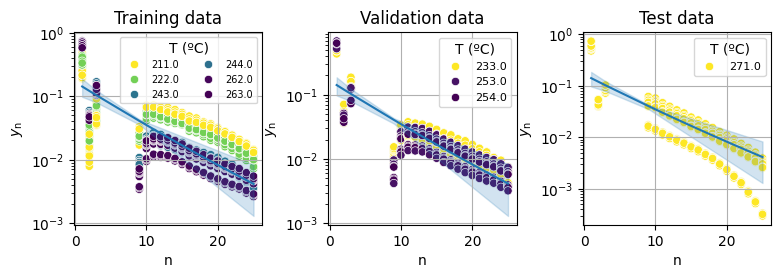

In [26]:
fig, ax = plt.subplots(1,3,figsize=(9, 2.5))
plt.subplots_adjust(wspace=0.35)

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_training)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[0], hue_order= [210,220,240,260])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[0], errorbar = ("pi", 100))

ax[0].grid('both')
ax[0].legend(title = 'T (ºC)', fontsize = 7, ncols = 2)
ax[0].set_ylabel(r'$y_\mathrm{n}$')
ax[0].set_yscale('log')
ax[0].set_title('Training data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_validation)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[1])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[1], errorbar = ("pi", 100))

ax[1].grid('both')
ax[1].legend(title = 'T (ºC)', fontsize = 8)
ax[1].set_ylabel(r'$y_\mathrm{n}$')
ax[1].set_yscale('log')
ax[1].set_title('Validation data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_test)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[2])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[2], errorbar = ("pi", 100))

ax[2].grid('both')
ax[2].legend(title = 'T (ºC)', fontsize = 8)
ax[2].set_ylabel(r'$y_\mathrm{n}$')
ax[2].set_yscale('log')
ax[2].set_title('Test data')

fig_name = 'y_n_distribution.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

plt.show()

In [27]:
alphas.loc[data.training].alpha.mean()

np.float64(0.8687170535603722)

In [28]:
alphas.loc[data.training].alpha.std()

np.float64(0.030434857794553235)

In [29]:
np.save('param_alpha.npy', alpha_params)

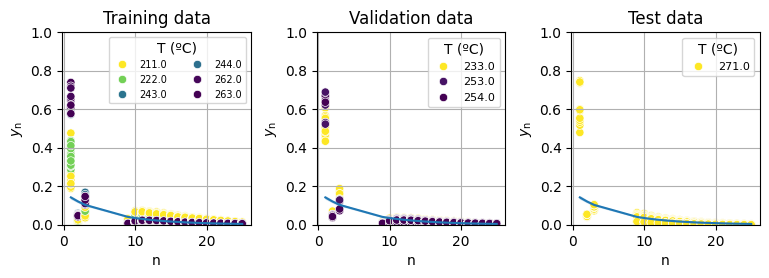

In [30]:
fig, ax = plt.subplots(1,3,figsize=(9, 2.5))
plt.subplots_adjust(wspace=0.35)

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_training)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[0], hue_order= [210,220,240,260])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[0])

ax[0].grid('both')
ax[0].legend(title = 'T (ºC)', fontsize = 7, ncols = 2)
ax[0].set_ylabel(r'$y_\mathrm{n}$')
ax[0].set_yscale('linear')
ax[0].set_ylim(0,1)
ax[0].set_title('Training data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_validation)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[1])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[1])

ax[1].grid('both')
ax[1].legend(title = 'T (ºC)', fontsize = 8)
ax[1].set_ylabel(r'$y_\mathrm{n}$')
ax[1].set_yscale('linear')
ax[1].set_ylim(0,1)
ax[1].set_title('Validation data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_test)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[2])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[2])

ax[2].grid('both')
ax[2].legend(title = 'T (ºC)', fontsize = 8)
ax[2].set_ylabel(r'$y_\mathrm{n}$')
ax[2].set_yscale('linear')
ax[2].set_ylim(0,1)
ax[2].set_title('Test data')

# fig_name = 'y_n_distribution.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')

plt.show()

In [31]:
alpha_params

array([ 1.62628872e+00, -1.49497171e-03])